In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model as skt
import seaborn as sns

In [2]:
df=pd.read_csv("economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
df.drop(columns=["Unnamed: 0"] , axis=1)

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256
5,2017,7,2.50,5.6,1254
6,2017,6,2.50,5.5,1234
7,2017,5,2.25,5.5,1195
8,2017,4,2.25,5.5,1159
9,2017,3,2.25,5.6,1167


In [4]:
df.isnull().sum()

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

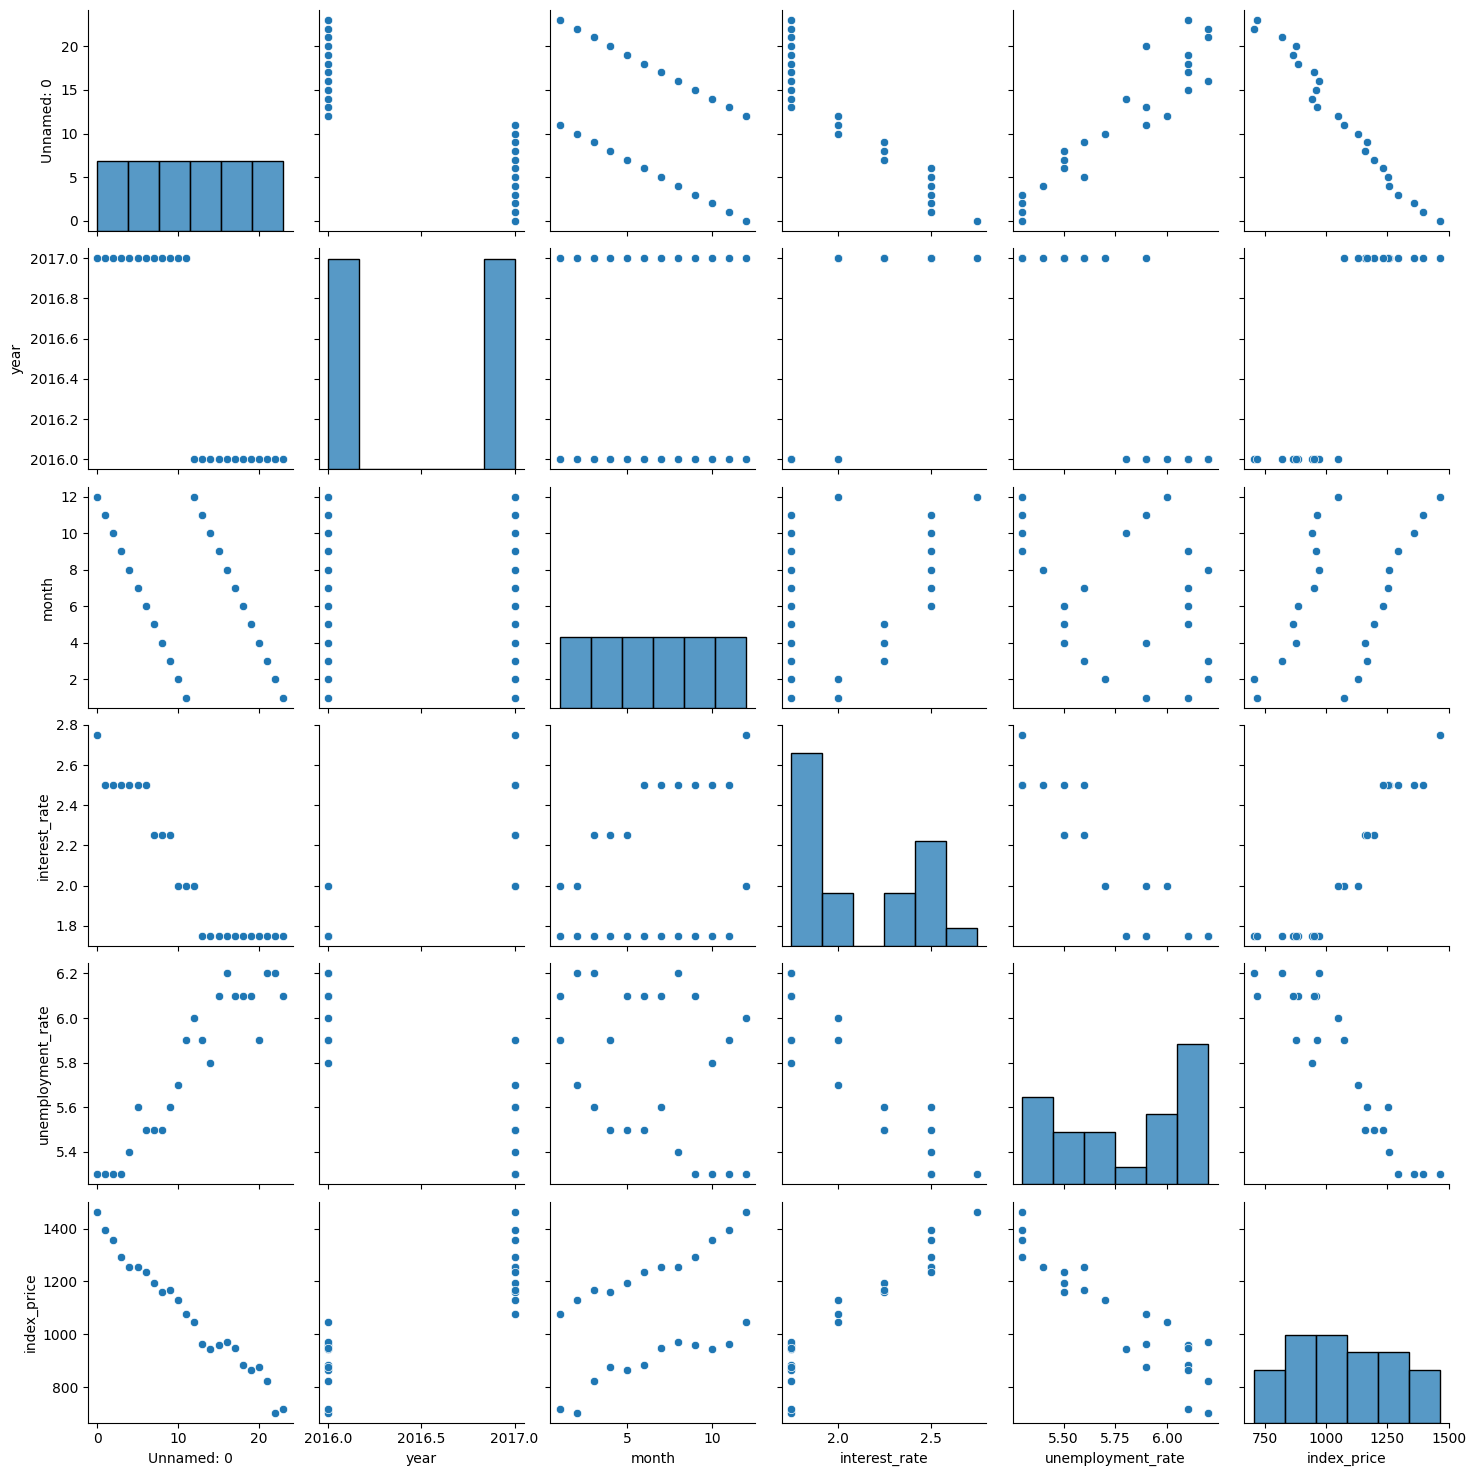

In [5]:
sns.pairplot(df)

In [6]:
df.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


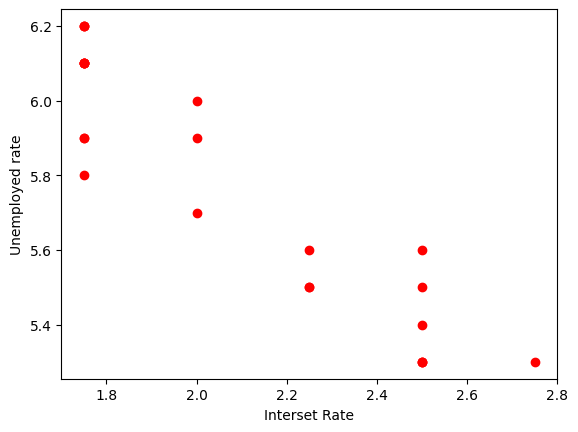

In [7]:
plt.figure()
plt.scatter(df["interest_rate"] , df["unemployment_rate"],color='r')
plt.xlabel("Interset Rate")
plt.ylabel("Unemployed rate")
plt.show()

In [8]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split

Xtrain , Xtest , yTrain , yTest = train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scalar = StandardScaler()
Xtrain=scalar.fit_transform(Xtrain)
Xtest=scalar.fit_transform(Xtest)

In [12]:
Xtrain

array([[ 0.15426662, -0.89442719,  1.25692828, -0.90115511,  0.37908503],
       [-1.51181292,  1.11803399,  1.25692828,  1.31077107, -1.48187786],
       [ 1.26498632, -0.89442719, -1.12462004, -0.90115511,  1.30956648],
       [-0.95645307,  1.11803399,  0.06615412,  1.31077107, -0.55139641],
       [-1.37297296,  1.11803399,  0.95923474,  1.31077107, -1.48187786],
       [ 0.01542666, -0.89442719,  1.55462182, -0.16384638,  0.68924552],
       [ 0.43194655, -0.89442719,  0.6615412 , -0.90115511,  0.999406  ],
       [-1.23413299,  1.11803399,  0.6615412 ,  1.31077107, -1.48187786],
       [-1.09529303,  1.11803399,  0.36384766,  1.31077107, -1.17171738],
       [ 1.40382628, -0.89442719, -1.42231358, -0.90115511,  1.30956648],
       [ 0.70962647, -0.89442719,  0.06615412, -0.90115511,  0.999406  ],
       [ 1.12614636, -0.89442719, -0.8269265 , -0.90115511,  0.37908503],
       [ 1.54266624, -0.89442719, -1.72000712, -0.90115511,  0.999406  ],
       [-0.67877315,  1.11803399, -0.5

In [13]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

regression.fit(Xtrain , yTrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
from sklearn.model_selection import cross_val_score

